# Credit Card Fraud Detection — Model Explainability

## Notebook 4: Global and Local Explainability of the Final Fraud Detection Model

This notebook explains the final optimized fraud detection model selected in Notebook 3.

The goal is not only to know that the model performs well, but to understand **why** it makes its predictions. In fraud detection, explainability is especially important because model decisions may influence customer experience, fraud investigations, and trust in automated systems.


## Objectives

This notebook will:

1. load the processed train and test feature sets
2. load the final optimized model and decision threshold
3. reproduce final model predictions
4. examine global feature importance
5. use SHAP to explain feature contributions
6. inspect high-confidence fraud and legitimate cases
7. compare correctly detected and missed fraud cases
8. identify what the model appears to learn about fraud behavior


## Why explainability matters

A high-performing model is not sufficient on its own. Financial fraud systems also need to support:

- transparency
- trust
- auditability
- interpretation of flagged cases
- communication of risk drivers

This notebook therefore focuses on turning model performance into model understanding.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [2]:
OCEAN_PALETTE = [
    "#DFF3F0",
    "#BFEAE5",
    "#79D0D3",
    "#3E9FBF",
    "#1F6F8B",
    "#174A7E",
    "#0F2F5F",
    "#081F3F",
    "#04162E"
]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

---
## 1. Load Feature Sets and Saved Artifacts

This notebook uses:
- the processed train and test datasets from Notebook 2
- the final optimized model from Notebook 3
- the best decision threshold selected during threshold optimization

In [3]:
TRAIN_FEATURES_PATH = "/kaggle/input/notebooks/nomusashongwe/02-feature-engineering/fraud_train_features.csv"
TEST_FEATURES_PATH = "/kaggle/input/notebooks/nomusashongwe/02-feature-engineering/fraud_test_features.csv"

MODEL_PATH = "/kaggle/input/notebooks/nomusashongwe/03-modeling-and-optimization/final_optimized_model.pkl"
THRESHOLD_PATH = "/kaggle/input/notebooks/nomusashongwe/03-modeling-and-optimization/final_best_threshold.pkl"

In [4]:
train_processed = pd.read_csv(TRAIN_FEATURES_PATH)
test_processed = pd.read_csv(TEST_FEATURES_PATH)

final_model = joblib.load(MODEL_PATH)
best_threshold = joblib.load(THRESHOLD_PATH)

print("Train shape:", train_processed.shape)
print("Test shape:", test_processed.shape)
print("Loaded threshold:", best_threshold)
print("Loaded model:", type(final_model))

Train shape: (1296675, 90)
Test shape: (555719, 90)
Loaded threshold: 0.1
Loaded model: <class 'xgboost.sklearn.XGBClassifier'>


---
## 2. Split Features and Target

In [5]:
target_col = "is_fraud"

X_train = train_processed.drop(columns=[target_col]).copy()
y_train = train_processed[target_col].copy()

X_test = test_processed.drop(columns=[target_col]).copy()
y_test = test_processed[target_col].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1296675, 89)
X_test shape: (555719, 89)
y_train shape: (1296675,)
y_test shape: (555719,)


---
## 3. Reproduce Final Model Predictions

Before interpreting the model, the notebook confirms the final prediction behavior using the saved threshold.

In [6]:
y_test_prob = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

final_metrics = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC", "Threshold"],
    "Value": [
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_prob),
        average_precision_score(y_test, y_test_prob),
        best_threshold
    ]
})

display(final_metrics)

,Metric,Value
0,Precision,0.8597
1,Recall,0.8401
2,F1-score,0.8498
3,ROC-AUC,0.9987
4,PR-AUC,0.9015
5,Threshold,0.1000


In [7]:
print(classification_report(y_test, y_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9994    0.9995    0.9994    553574
           1     0.8597    0.8401    0.8498      2145

    accuracy                         0.9989    555719
   macro avg     0.9296    0.9198    0.9246    555719
weighted avg     0.9988    0.9989    0.9988    555719



---
## 4. Final Confusion Matrix

In [8]:
final_cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    final_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

,Predicted 0,Predicted 1
Actual 0,553280,294
Actual 1,343,1802


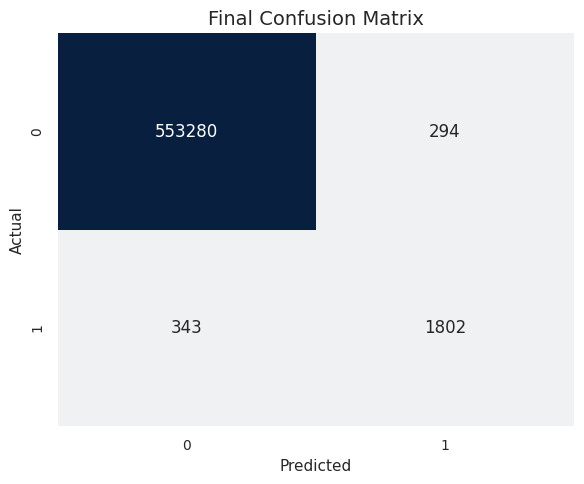

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap=sns.light_palette(OCEAN_PALETTE[7], as_cmap=True),
    cbar=False
)
plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

---
## 5. Global Feature Importance

Tree-based feature importance provides a first high-level summary of which engineered variables most strongly influence the final model.

In [10]:
if hasattr(final_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(feature_importance_df.head(20))

,feature,importance
31,customer_avg_same_day,0.3468
30,customer_amt_same_day,0.2281
80,amt_band_Low,0.0506
52,night_amt,0.0321
79,amt_band_High,0.0295
53,night_log_amt,0.0210
0,amt,0.0157
59,category_gas_transport,0.0153
46,city_fraud_rate,0.0147
58,category_food_dining,0.0110


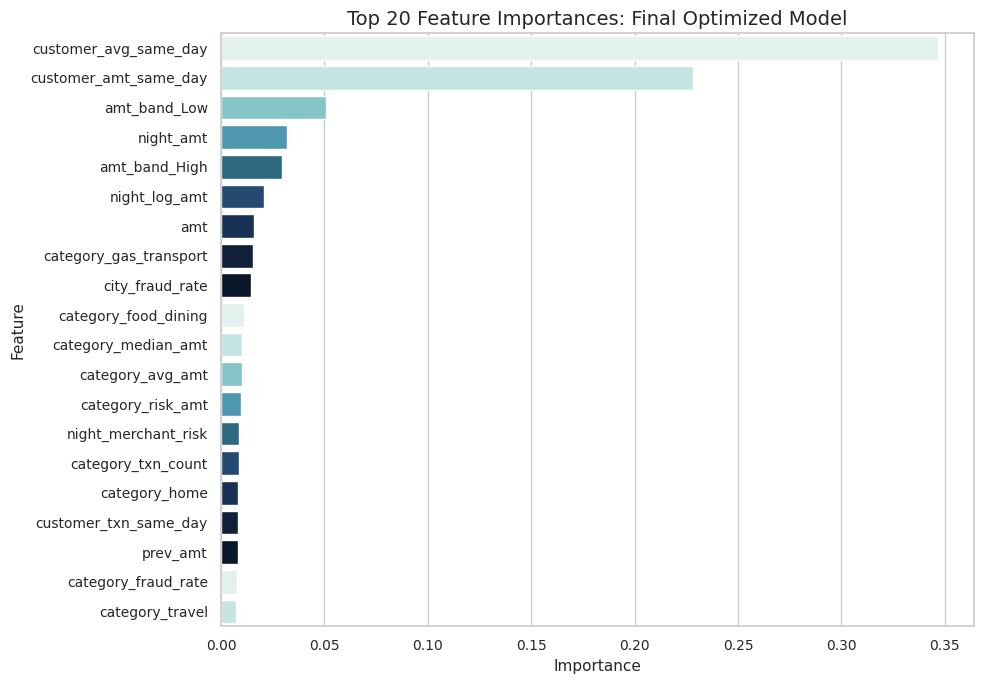

In [11]:
top_feature_importance = feature_importance_df.head(20).copy()

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_feature_importance,
    x="importance",
    y="feature",
    palette=OCEAN_PALETTE[:len(top_feature_importance)]
)
plt.title("Top 20 Feature Importances: Final Optimized Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

---
## 6. Interpretation of the Top Engineered Drivers

Several high-importance features deserve direct interpretation:

- `customer_avg_same_day` and `customer_amt_same_day` suggest that same-day spending behavior is highly informative
- amount band indicators imply that the model distinguishes fraud risk across transaction amount regimes
- `night_amt` and `night_log_amt` suggest that timing and amount interact meaningfully
- category- and city-level fraud context features indicate that broader transaction environment matters

These results imply that the model is learning structured fraud behavior rather than random correlations.

---
## 7. Build an Explainability Dataset

A combined interpretation frame is constructed to support:
- global analysis
- local case review
- error analysis

In [12]:
explain_df = X_test.copy()
explain_df["actual"] = y_test.values
explain_df["pred_prob"] = y_test_prob
explain_df["pred_label"] = y_test_pred

explain_df["prediction_type"] = np.select(
    [
        (explain_df["actual"] == 1) & (explain_df["pred_label"] == 1),
        (explain_df["actual"] == 1) & (explain_df["pred_label"] == 0),
        (explain_df["actual"] == 0) & (explain_df["pred_label"] == 1),
        (explain_df["actual"] == 0) & (explain_df["pred_label"] == 0),
    ],
    [
        "True Positive",
        "False Negative",
        "False Positive",
        "True Negative"
    ],
    default="Other"
)

display(explain_df.head())

,amt,lat,long,city_pop,merch_lat,merch_long,trans_hour,trans_day,trans_dayofweek,trans_month,trans_year,is_weekend,is_night_transaction,age,log_amt,amt_squared,is_high_value_txn,log_city_pop,prev_amt,amt_change_from_prev,amt_ratio_to_prev,time_since_last_txn_sec,cust_txn_count,cust_avg_amt,cust_median_amt,cust_std_amt,amt_vs_cust_mean,amt_vs_cust_median,zscore_amt_within_customer,customer_txn_same_day,customer_amt_same_day,customer_avg_same_day,amt_share_of_day_total,merchant_txn_count,merchant_fraud_rate,merchant_avg_amt,merchant_median_amt,category_txn_count,category_fraud_rate,category_avg_amt,category_median_amt,state_txn_count,state_fraud_rate,state_avg_amt,state_median_amt,city_txn_count,city_fraud_rate,city_avg_amt,city_median_amt,merchant_risk_amt,category_risk_amt,state_risk_amt,night_amt,night_log_amt,night_merchant_risk,night_category_risk,distance_cust_merchant,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_F,gender_M,age_band_25-34,age_band_35-44,age_band_45-54,age_band_55-64,age_band_65+,age_band_Under 25,amt_band_High,amt_band_Low,amt_band_Medium,amt_band_Very High,amt_band_Very Low,city_pop_band_High,city_pop_band_Low,city_pop_band_Medium,city_pop_band_Very High,city_pop_band_Very Low,actual,pred_prob,pred_label,prediction_type
0,0.3388,0.8801,-1.3569,-0.2887,0.8627,-1.3292,0.0286,0.6130,1.3327,-0.0416,1.5771,1,0,-0.6701,1.0083,-0.0086,0,-0.3898,-0.4386,-0.0001,-0.1824,-0.6849,-1.3409,-0.1984,-0.4547,0.5275,0.3655,0.3975,0.3232,-0.9382,-0.3143,0.3316,0.9733,0.6472,-0.7421,-0.5765,0.2561,0.9325,-0.7791,-0.5857,0.2437,-0.8498,-0.0332,1.3266,1.4262,1.4600,0.0077,0.3413,1.1458,-0.1762,-0.1864,0.1518,-0.2133,-0.5131,-0.3944,-0.4017,-1.3885,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,0,0.0000,0,True Negative
1,0.0510,0.8801,-1.3569,-0.2887,0.7154,-1.3402,0.4686,0.6130,1.3327,-0.0416,1.5771,1,0,-0.6701,0.6534,-0.0140,0,-0.3898,0.3396,-0.2101,-0.1619,-0.4319,-1.3394,-0.1984,-0.4547,0.5275,0.0755,0.1079,0.0668,-0.9382,-0.3143,0.3316,0.2433,-0.8500,-0.3663,-0.5263,-0.9930,-0.8742,-0.4939,-0.3616,-0.9921,-0.8498,-0.0332,1.3266,1.4262,1.4600,0.0077,0.3413,1.1458,-0.1223,-0.1570,0.0184,-0.2133,-0.5131,-0.3944,-0.4017,0.2593,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0,0.0000,0,True Negative
2,-0.0318,0.8801,-1.3569,-0.2887,1.0559,-1.4141,-0.8514,0.7262,-1.3969,-0.0416,1.5771,0,0,-0.6699,0.5118,-0.0151,0,-0.3898,0.0516,-0.0605,-0.1553,0.4962,-1.3379,-0.1984,-0.4547,0.5275,-0.0079,0.0246,-0.0069,-0.9382,-0.4184,0.0652,0.3720,1.0469,-0.0047,-0.3252,0.7548,1.2877,-0.2040,-0.3353,0.7669,-0.8498,-0.0332,1.3266,1.4262,1.4600,0.0077,0.3413,1.1458,-0.0718,-0.1186,-0.0199,-0.2133,-0.5131,-0.3944,-0.4017,1.6215,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0,0.0000,0,True Negative
3,0.1085,0.8801,-1.3569,-0.2887,0.9802,-1.3787,0.3220,0.7262,-1.3969,-0.0416,1.5771,0,0,-0.6699,0.7385,-0.0131,0,-0.3898,-0.0313,0.1022,-0.1385,-0.1102,-1.3365,-0.1984,-0.4547,0.5275,0.1335,0.1657,0.1180,-0.9382,-0.4184,0.0652,0.8446,0.3700,-0.3206,-0.6335,0.1900,0.5135,-0.6848,-0.6212,0.2038,-0.8498,-0.0332,1.3266,1.4262,1.4600,0.0077,0.3413,1.1458,-0.0869,-0.1960,0.0451,-0.2133,-0.5131,-0.3944,-0.4017,-0.4869,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0,0

---
## 8. Probability Distribution by Actual Class

This section checks how well the model separates fraud and legitimate transactions at the probability level.

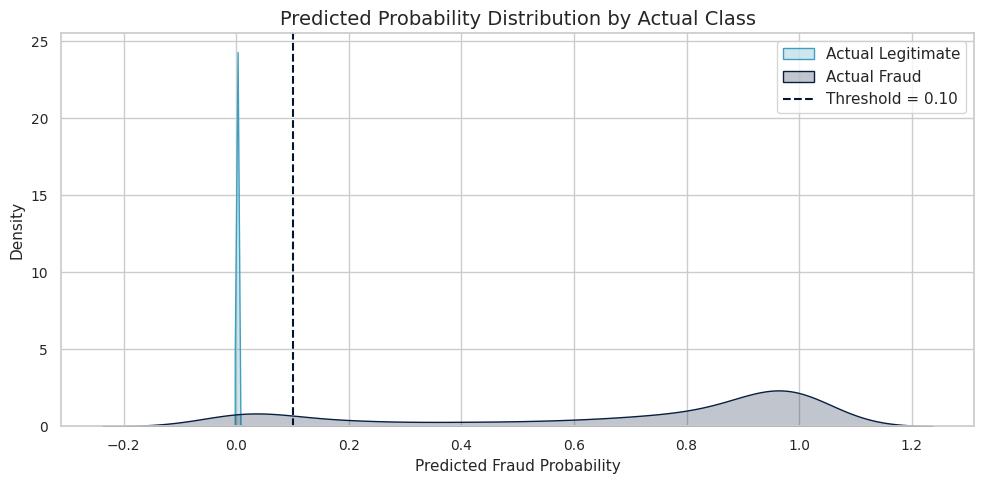

In [13]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=explain_df[explain_df["actual"] == 0],
    x="pred_prob",
    fill=True,
    color=OCEAN_PALETTE[3],
    label="Actual Legitimate"
)

sns.kdeplot(
    data=explain_df[explain_df["actual"] == 1],
    x="pred_prob",
    fill=True,
    color=OCEAN_PALETTE[7],
    label="Actual Fraud"
)

plt.axvline(best_threshold, linestyle="--", color=OCEAN_PALETTE[8], label=f"Threshold = {best_threshold:.2f}")
plt.title("Predicted Probability Distribution by Actual Class")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

---
## 9. SHAP Explainer Setup

SHAP is used to estimate how each feature contributes to individual predictions and global model behavior.

In [14]:
sample_size_background = min(5000, len(X_train))
sample_size_explain = min(5000, len(X_test))

X_train_background = X_train.sample(sample_size_background, random_state=42)
X_test_explain = X_test.sample(sample_size_explain, random_state=42)
y_test_explain = y_test.loc[X_test_explain.index]

print("Background sample shape:", X_train_background.shape)
print("Explain sample shape:", X_test_explain.shape)

Background sample shape: (5000, 89)
Explain sample shape: (5000, 89)


In [15]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_explain)

In [16]:
if isinstance(shap_values, list):
    shap_values = shap_values[1]

---
## 10. SHAP Summary Plot

The SHAP summary plot shows both:
- which features matter most globally
- whether high or low feature values push the model toward fraud

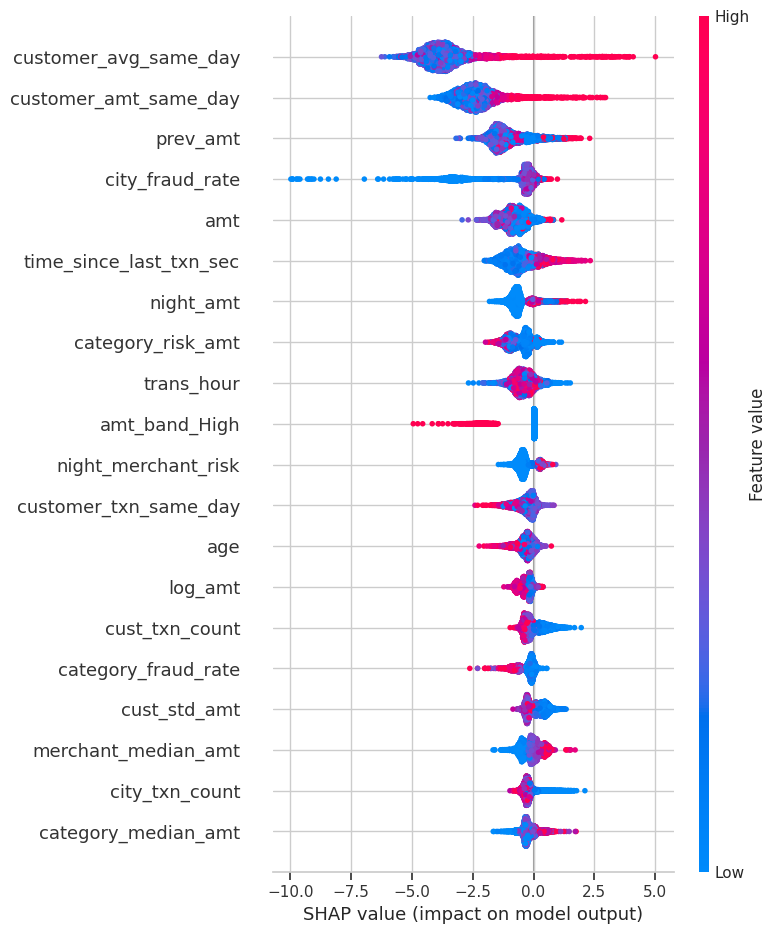

In [17]:
shap.summary_plot(shap_values, X_test_explain, plot_type="dot", max_display=20)

---
## 11. SHAP Global Importance Bar Plot

In [18]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": X_test_explain.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance_df.head(20))

,feature,mean_abs_shap
31,customer_avg_same_day,3.5727
30,customer_amt_same_day,2.3318
18,prev_amt,1.1450
46,city_fraud_rate,0.9532
0,amt,0.8305
21,time_since_last_txn_sec,0.6792
52,night_amt,0.6515
50,category_risk_amt,0.5940
6,trans_hour,0.4750
79,amt_band_High,0.4552


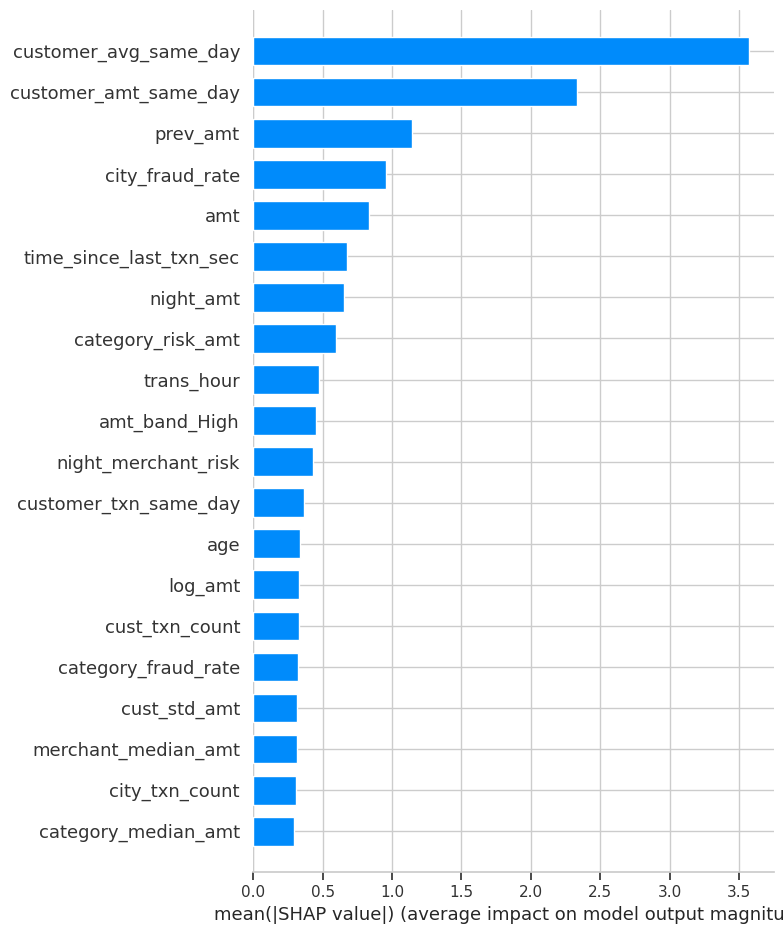

In [19]:
shap.summary_plot(shap_values, X_test_explain, plot_type="bar", max_display=20)

---
## 12. Compare Model Importance and SHAP Importance

Standard feature importance and SHAP importance are not always identical. Comparing them helps reveal whether a feature is globally important only in specific tree structures or whether it consistently drives predictions.

In [20]:
importance_compare = feature_importance_df.merge(
    shap_importance_df,
    on="feature",
    how="inner"
).sort_values("mean_abs_shap", ascending=False)

display(importance_compare.head(20))

,feature,importance,mean_abs_shap
0,customer_avg_same_day,0.3468,3.5727
1,customer_amt_same_day,0.2281,2.3318
17,prev_amt,0.0080,1.1450
8,city_fraud_rate,0.0147,0.9532
6,amt,0.0157,0.8305
42,time_since_last_txn_sec,0.0028,0.6792
3,night_amt,0.0321,0.6515
12,category_risk_amt,0.0094,0.5940
62,trans_hour,0.0012,0.4750
4,amt_band_High,0.0295,0.4552


---
## 13. SHAP Dependence Analysis for Top Features

Dependence plots show how individual feature values influence fraud probability in the final model.

In [21]:
top_shap_features = shap_importance_df.head(5)["feature"].tolist()
top_shap_features

['customer_avg_same_day',
 'customer_amt_same_day',
 'prev_amt',
 'city_fraud_rate',
 'amt']

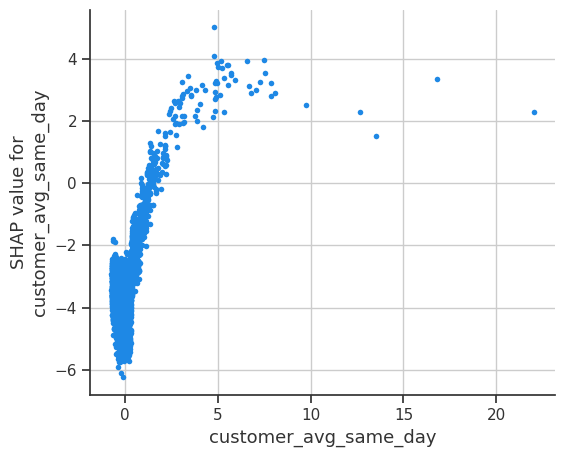

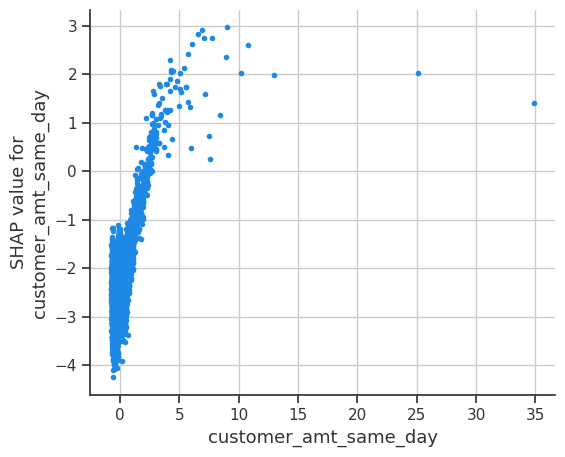

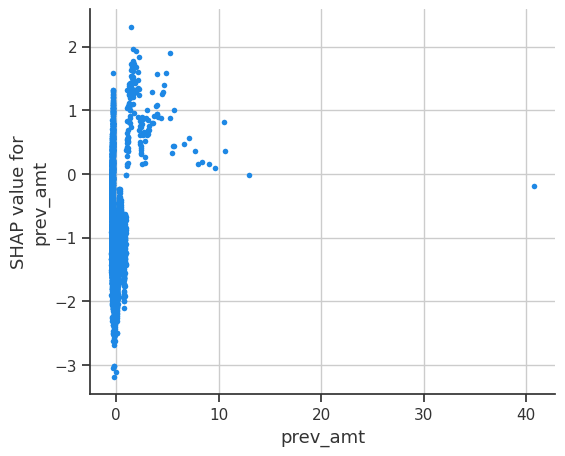

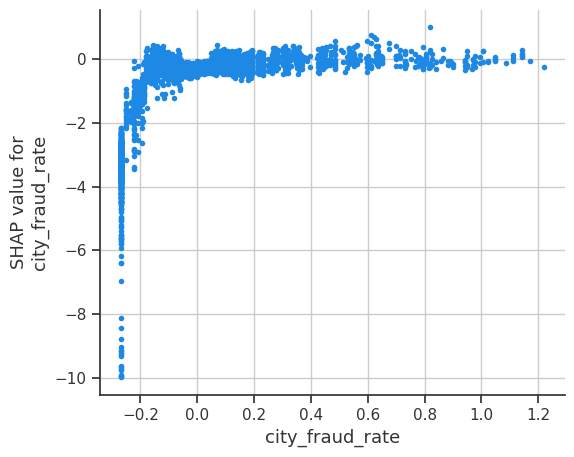

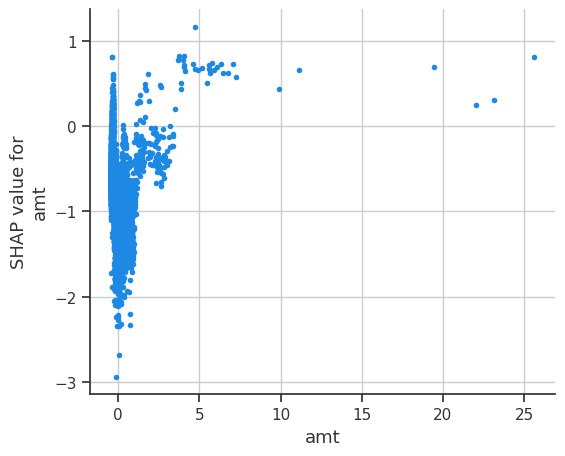

In [22]:
for feature in top_shap_features:
    shap.dependence_plot(feature, shap_values, X_test_explain, interaction_index=None)

---
## 14. Local Explainability: Highest-Risk Fraud Cases

This section examines the fraud transactions assigned the highest fraud probability by the model.

In [23]:
fraud_cases = explain_df[explain_df["actual"] == 1].copy()
top_fraud_cases = fraud_cases.sort_values("pred_prob", ascending=False).head(5)

display(top_fraud_cases[["pred_prob", "pred_label", "prediction_type"] + top_shap_features])

,pred_prob,pred_label,prediction_type,customer_avg_same_day,customer_amt_same_day,prev_amt,city_fraud_rate,amt
11302,1.0000,1,True Positive,5.3759,11.2312,1.5684,-0.0008,1.3913
13868,1.0000,1,True Positive,6.2558,7.4763,5.2917,-0.0212,1.3385
7546,1.0000,1,True Positive,3.7835,4.5770,5.8012,-0.0000,1.3032
13863,1.0000,1,True Positive,6.2558,7.4763,5.0449,-0.0212,1.4496
13864,1.0000,1,True Positive,6.2558,7.4763,1.4513,-0.0212,1.5285


---
## 15. SHAP Force-Style Local Explanations for Top Fraud Cases> 

In [24]:
top_fraud_indices = top_fraud_cases.index.tolist()

for idx in top_fraud_indices:
    row_position = X_test_explain.index.get_indexer([idx])[0] if idx in X_test_explain.index else -1
    if row_position != -1:
        print(f"Fraud case index: {idx}")
        shap.initjs()
        display(shap.force_plot(
            explainer.expected_value,
            shap_values[row_position],
            X_test_explain.iloc[row_position],
            matplotlib=True
        ))

---
## 16. Local Explainability: Highest-Confidence Legitimate Cases

The notebook also examines confidently legitimate transactions to understand what a strong non-fraud profile looks like.

In [25]:
legit_cases = explain_df[explain_df["actual"] == 0].copy()
top_legit_cases = legit_cases.sort_values("pred_prob", ascending=True).head(5)

display(top_legit_cases[["pred_prob", "pred_label", "prediction_type"] + top_shap_features])

,pred_prob,pred_label,prediction_type,customer_avg_same_day,customer_amt_same_day,prev_amt,city_fraud_rate,amt
94278,0.0000,0,True Negative,0.0990,1.2477,-0.1749,-0.2684,0.0200
361522,0.0000,0,True Negative,-0.3404,-0.3387,-0.1334,-0.2684,-0.3648
433735,0.0000,0,True Negative,-0.0492,0.3548,-0.1002,-0.2072,-0.0446
386478,0.0000,0,True Negative,-0.3772,-0.5191,-0.1756,-0.0510,-0.3713
386688,0.0000,0,True Negative,-0.4064,0.4614,-0.2477,-0.0510,-0.3838


---
## 17. Compare Fraud vs Legitimate Profiles for Top Features

In [26]:
profile_compare = pd.DataFrame({
    "Fraud Mean": explain_df.loc[explain_df["actual"] == 1, top_shap_features].mean(),
    "Legitimate Mean": explain_df.loc[explain_df["actual"] == 0, top_shap_features].mean()
}).reset_index().rename(columns={"index": "feature"})

display(profile_compare)

,feature,Fraud Mean,Legitimate Mean
0,customer_avg_same_day,4.8611,-0.0290
1,customer_amt_same_day,5.9434,0.0737
2,prev_amt,2.5359,-0.0160
3,city_fraud_rate,-0.0293,-0.0202
4,amt,2.8569,-0.0171


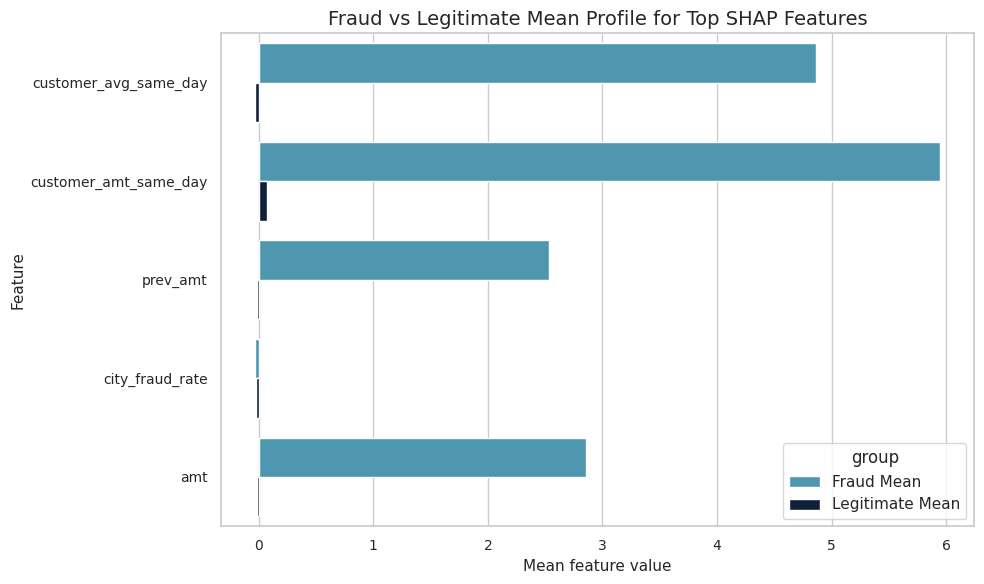

In [27]:
profile_compare_melted = profile_compare.melt(
    id_vars="feature",
    var_name="group",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=profile_compare_melted,
    x="value",
    y="feature",
    hue="group",
    palette=[OCEAN_PALETTE[3], OCEAN_PALETTE[7]]
)
plt.title("Fraud vs Legitimate Mean Profile for Top SHAP Features")
plt.xlabel("Mean feature value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

---
## 18. Error Analysis: False Negatives

False negatives are missed fraud cases. These are especially important because they represent fraud that escaped detection.

In [28]:
false_negatives = explain_df[explain_df["prediction_type"] == "False Negative"].copy()
print("Number of false negatives:", len(false_negatives))

display(false_negatives.sort_values("pred_prob", ascending=False).head(10))

Number of false negatives: 343


,amt,lat,long,city_pop,merch_lat,merch_long,trans_hour,trans_day,trans_dayofweek,trans_month,trans_year,is_weekend,is_night_transaction,age,log_amt,amt_squared,is_high_value_txn,log_city_pop,prev_amt,amt_change_from_prev,amt_ratio_to_prev,time_since_last_txn_sec,cust_txn_count,cust_avg_amt,cust_median_amt,cust_std_amt,amt_vs_cust_mean,amt_vs_cust_median,zscore_amt_within_customer,customer_txn_same_day,customer_amt_same_day,customer_avg_same_day,amt_share_of_day_total,merchant_txn_count,merchant_fraud_rate,merchant_avg_amt,merchant_median_amt,category_txn_count,category_fraud_rate,category_avg_amt,category_median_amt,state_txn_count,state_fraud_rate,state_avg_amt,state_median_amt,city_txn_count,city_fraud_rate,city_avg_amt,city_median_amt,merchant_risk_amt,category_risk_amt,state_risk_amt,night_amt,night_log_amt,night_merchant_risk,night_category_risk,distance_cust_merchant,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_F,gender_M,age_band_25-34,age_band_35-44,age_band_45-54,age_band_55-64,age_band_65+,age_band_Under 25,amt_band_High,amt_band_Low,amt_band_Medium,amt_band_Very High,amt_band_Very Low,city_pop_band_High,city_pop_band_Low,city_pop_band_Medium,city_pop_band_Very High,city_pop_band_Very Low,actual,pred_prob,pred_label,prediction_type
193440,-0.3168,0.3109,1.1173,-0.2242,0.3521,1.1341,1.4954,-1.3125,-0.4870,1.4214,1.5771,0,1,-0.6065,-0.3952,-0.0173,0,0.6512,-0.3220,0.0040,-0.1482,-0.6068,-0.7389,1.1814,0.3485,-0.0193,-0.4632,-0.3621,-0.5270,0.6265,3.3560,2.2439,-0.9670,0.2833,-0.5516,-0.6348,0.2358,0.5135,-0.6848,-0.6212,0.2038,1.5255,-0.0183,0.4722,1.2840,-0.5505,-0.2684,0.9214,0.3211,-0.2730,-0.2883,-0.1515,0.0094,1.2997,0.2906,0.1380,-1.5298,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,1,0.0986,0,False Negative
554424,5.0193,-0.8579,0.6319,-0.2666,-0.7046,0.6319,-1.7315,-1.1992,1.3327,0.2510,1.5771,1,1,-1.1502,2.5142,0.4206,1,0.2718,1.7446,2.3901,-0.1007,0.4470,-1.2937,1.7740,0.7541,-0.0323,4.8401,4.9567,5.5442,1.8782,4.1032,1.5040,0.2069,-1.4156,1.7367,0.4448,-1.1179,-1.5547,1.6158,0.5097,-1.1388,-0.4625,0.2858,-1.4806,-1.4845,-1.0544,-0.2684,0.9488,0.4840,8.1078,7.7869,2.7288,9.7436,3.5488,3.4749,3.2891,-0.0415,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,1,0.0978,0,False Negative
17393,-0.3228,-1.2325,-0.6062,-0.2928,-1.0543,-0.5541,1.3487,-1.0859,-0.9420,1.1288,1.5771,0,1,-0.2204,-0.4327,-0.0173,0,-0.9587,-0.3117,-0.0080,-0.1525,-0.2120,-1.1786,2.2721,1.5906,0.0346,-0.6023,-0.5228,-0.6664,-0.3124,1.7113,2.3832,-0.9482,-0.4992,-0.8415,-1.0733,-0.3211,-0.4127,-0.6271,-1.0851,-0.3210,2.1154,-0.2569,0.3266,-0.1939,-1.5573,-0.2684,1.4792,1.7179,-0.2933,-0.2859,-0.1609,-0.0016,1.2707,-0.1129,0.2171,1.2497,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,1,0.0977,0,False Negative
251976,-0.3359,-0.4844,0.6576,-0.2826,-0.4905,0.7221,1.4954,0.3865,1.3327,0.2510,1.5771,1,1,-0.7839,-0.5206,-0.0174,0,-0.0825,-0.3299,-0.0042,-0.1515,-0.6595,-1.1314,1.2161,0.5664,-0.1607,-0.4867,-0.4085,-0.5980,0.9394,5.3962,3.1749,-0.9810,-0.3993,-0.6509,-1.1394,-0.3911,-0.4127,-0.6271,-1.0851,-0.3210,-0.4203,-0.3005,1.6257,0.7104,-0.0357,-0.2684,0.9384,0.4547,-0.2839,-0.2892,-0.1673,-0.0255,1.2028,0.1523,0.2171,0.4625,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,

In [29]:
if len(false_negatives) > 0:
    fn_profile = false_negatives[top_shap_features].mean().rename("False Negative Mean")
    tp_profile = explain_df[explain_df["prediction_type"] == "True Positive"][top_shap_features].mean().rename("True Positive Mean")

    error_compare = pd.concat([tp_profile, fn_profile], axis=1).reset_index().rename(columns={"index": "feature"})
    display(error_compare)

,feature,True Positive Mean,False Negative Mean
0,customer_avg_same_day,5.2110,3.0230
1,customer_amt_same_day,6.4555,3.2527
2,prev_amt,2.7807,1.2496
3,city_fraud_rate,0.0159,-0.2668
4,amt,3.1395,1.3721


---
## 19. Error Analysis: False Positives

False positives are legitimate transactions incorrectly flagged as fraud. These matter because they affect user experience and trust.

In [30]:
false_positives = explain_df[explain_df["prediction_type"] == "False Positive"].copy()
print("Number of false positives:", len(false_positives))

display(false_positives.sort_values("pred_prob", ascending=False).head(10))

Number of false positives: 294


,amt,lat,long,city_pop,merch_lat,merch_long,trans_hour,trans_day,trans_dayofweek,trans_month,trans_year,is_weekend,is_night_transaction,age,log_amt,amt_squared,is_high_value_txn,log_city_pop,prev_amt,amt_change_from_prev,amt_ratio_to_prev,time_since_last_txn_sec,cust_txn_count,cust_avg_amt,cust_median_amt,cust_std_amt,amt_vs_cust_mean,amt_vs_cust_median,zscore_amt_within_customer,customer_txn_same_day,customer_amt_same_day,customer_avg_same_day,amt_share_of_day_total,merchant_txn_count,merchant_fraud_rate,merchant_avg_amt,merchant_median_amt,category_txn_count,category_fraud_rate,category_avg_amt,category_median_amt,state_txn_count,state_fraud_rate,state_avg_amt,state_median_amt,city_txn_count,city_fraud_rate,city_avg_amt,city_median_amt,merchant_risk_amt,category_risk_amt,state_risk_amt,night_amt,night_log_amt,night_merchant_risk,night_category_risk,distance_cust_merchant,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_F,gender_M,age_band_25-34,age_band_35-44,age_band_45-54,age_band_55-64,age_band_65+,age_band_Under 25,amt_band_High,amt_band_Low,amt_band_Medium,amt_band_Very High,amt_band_Very Low,city_pop_band_High,city_pop_band_Low,city_pop_band_Medium,city_pop_band_Very High,city_pop_band_Very Low,actual,pred_prob,pred_label,prediction_type
161574,1.0700,0.6045,-1.3812,-0.2015,0.4781,-1.4020,-1.7315,-1.0859,-1.3969,0.2510,1.5771,0,1,-0.5788,1.5194,0.0159,1,0.7657,3.2720,-1.6042,-0.1691,-0.5418,-1.2243,1.1079,0.4651,-0.1329,0.9428,1.0188,1.1405,1.8782,7.8488,3.2461,-0.8110,0.8772,1.3241,2.2576,2.3142,0.9543,1.5486,2.2596,2.2871,-0.8498,-0.0332,1.3266,1.4262,0.4971,-0.0150,1.2848,0.5568,1.6745,1.8690,0.4906,2.5392,2.7797,2.9006,3.1972,-0.2457,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,0,0.9998,1,False Positive
472891,-0.3098,-0.8378,-0.0805,-0.2771,-0.7578,-0.1014,1.4954,-1.4257,-0.9420,1.4214,1.5771,0,1,-1.0592,-0.3541,-0.0173,0,0.0764,-0.2948,-0.0108,-0.1531,-0.6653,-0.1296,1.0834,0.5619,-0.1172,-0.4442,-0.3816,-0.5327,1.2524,4.1906,2.0538,-0.9709,-0.3842,-0.2615,-1.0889,-0.3443,-0.4127,-0.6271,-1.0851,-0.3210,-0.3865,-0.2140,1.2031,0.1669,1.0399,-0.0594,1.1612,0.5122,-0.2503,-0.2827,-0.1542,0.0222,1.3315,0.6942,0.2171,-1.0111,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,0,0.9998,1,False Positive
379770,1.3375,0.2142,0.5430,-0.2792,0.1048,0.4967,-1.4381,-0.7462,-0.4870,0.8362,1.5771,0,1,-1.0384,1.6454,0.0289,1,0.0216,-0.4162,1.2794,2.4105,-0.1982,-0.9883,0.6155,0.2164,-0.3739,1.2723,1.3189,1.7777,-0.6253,0.4884,1.3410,0.5523,0.6755,1.5793,2.2545,2.3371,0.9543,1.5486,2.2596,2.2871,0.2160,0.3880,0.6663,0.5786,-0.5346,-0.0560,0.6788,0.3133,2.2770,2.2562,0.7900,3.0271,2.8772,3.2557,3.1972,0.2570,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,0,0.9997,1,False Positive
147037,13.3102,0.5871,0.8702,-0.2792,0.7427,0.8921,-1.7315,0.8395,-0.0321,0.2510,1.5771,0,1,0.2718,3.2301,2.7628,1,0.0235,23.8296,-7.6604,-0.1639,-0.6564,-1.2420,0.2937,0.2053,1.0838,13.3730,13.3677,9.6425,0.0006,12.0321,12.3180,0.1523,0.5209,-0.1127,0.2725,-1.2119,0.6647,0.2678,0.4571,-1.2136,1.5255,-0.0183,0.4722,1.2840,-1.0464,0.1427,-0.1123,0.2689,6.7910,9.8843,6.2105,24.8682,4.1022,0.9012,1.4428,0.3758,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,0,0.9997,1,False

In [31]:
if len(false_positives) > 0:
    fp_profile = false_positives[top_shap_features].mean().rename("False Positive Mean")
    tn_profile = explain_df[explain_df["prediction_type"] == "True Negative"][top_shap_features].mean().rename("True Negative Mean")

    fp_compare = pd.concat([tn_profile, fp_profile], axis=1).reset_index().rename(columns={"index": "feature"})
    display(fp_compare)

,feature,True Negative Mean,False Positive Mean
0,customer_avg_same_day,-0.0311,3.8773
1,customer_amt_same_day,0.0717,3.7495
2,prev_amt,-0.0175,2.8384
3,city_fraud_rate,-0.0203,0.0912
4,amt,-0.0179,1.6297


---
## 20. Distribution of Prediction Types

In [32]:
prediction_type_summary = (
    explain_df["prediction_type"]
    .value_counts()
    .rename_axis("prediction_type")
    .reset_index(name="count")
)

display(prediction_type_summary)

,prediction_type,count
0,True Negative,553280
1,True Positive,1802
2,False Negative,343
3,False Positive,294


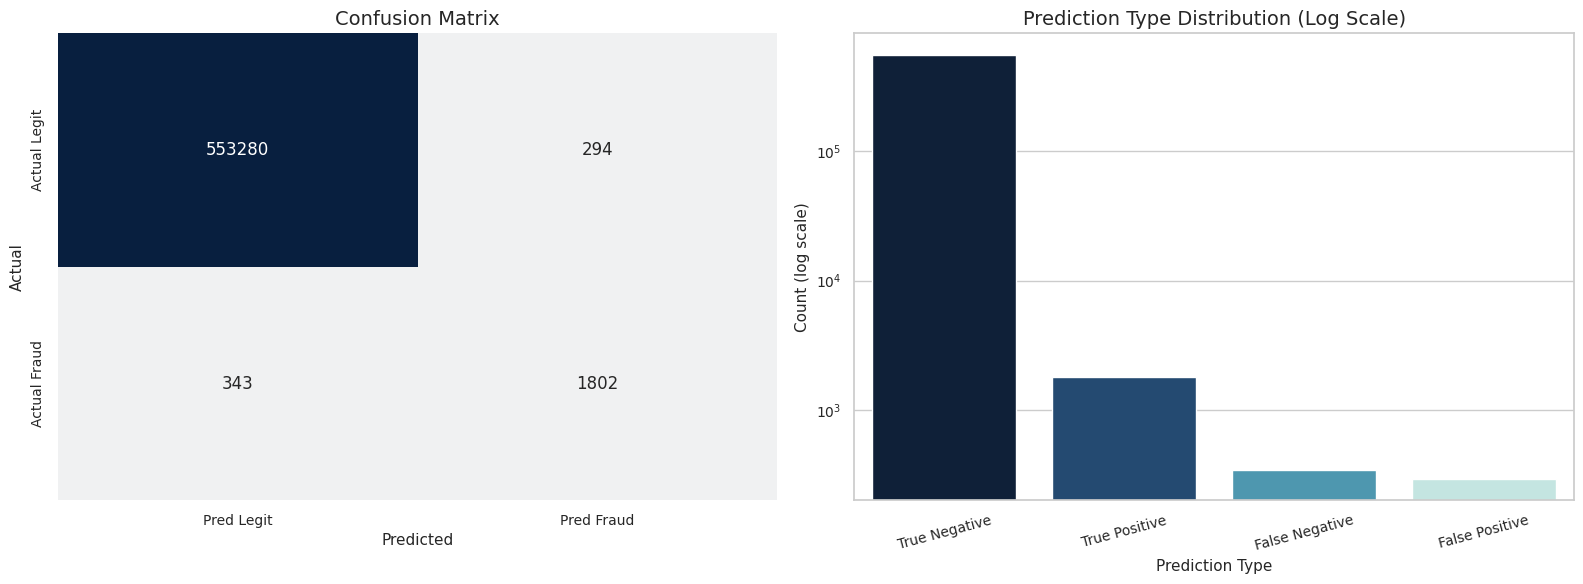

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Legit", "Actual Fraud"],
    columns=["Pred Legit", "Pred Fraud"]
)

# --- Prediction Type Summary ---
prediction_type_summary = (
    explain_df["prediction_type"]
    .value_counts()
    .rename_axis("prediction_type")
    .reset_index(name="count")
)

# --- Plot Side-by-Side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap=sns.light_palette(OCEAN_PALETTE[7], as_cmap=True),
    cbar=False,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix", fontsize=14)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Log-Scale Distribution
sns.barplot(
    data=prediction_type_summary,
    x="prediction_type",
    y="count",
    palette=[
        OCEAN_PALETTE[7],
        OCEAN_PALETTE[5],
        OCEAN_PALETTE[3],
        OCEAN_PALETTE[1]
    ],
    ax=axes[1]
)

axes[1].set_yscale("log")
axes[1].set_title("Prediction Type Distribution (Log Scale)", fontsize=14)
axes[1].set_xlabel("Prediction Type")
axes[1].set_ylabel("Count (log scale)")
axes[1].tick_params(axis="x", rotation=15)

# --- Final Layout ---
plt.tight_layout()
plt.show()

---
## 21. Final Optimized Model Evaluation

After extensive feature engineering, model selection, and threshold tuning, the final optimized XGBoost model demonstrates strong performance in detecting fraudulent transactions.

### Key Performance Metrics

- **Precision (Fraud Class)**: 0.8597  
- **Recall (Fraud Class)**: 0.8401  
- **F1-score**: 0.8498  
- **ROC-AUC**: 0.9987  
- **PR-AUC**: 0.9015  
- **Optimal Threshold**: 0.10  

### Interpretation

The model achieves a strong balance between precision and recall:

- A **recall of 84%** indicates that the majority of fraud cases are successfully detected.
- A **precision of ~86%** ensures that most flagged transactions are indeed fraudulent.
- The **high ROC-AUC (≈1.0)** reflects excellent separability between fraud and legitimate transactions.
- The **PR-AUC (0.90)** is particularly important in this imbalanced dataset, confirming strong performance on the minority (fraud) class.

### Confusion Matrix Insights

- **True Positives (Fraud correctly detected)**: 1,802  
- **False Negatives (Missed fraud cases)**: 343  
- **False Positives (Incorrect fraud alerts)**: 294  
- **True Negatives (Correct legitimate predictions)**: 553,280  

The relatively low number of false positives and false negatives highlights the model's robustness.

### Threshold Optimization Impact

The decision threshold was lowered to **0.10**, which:

- Significantly improves **recall** (reducing missed fraud)
- Slightly sacrifices precision, but remains within an acceptable range
- Aligns with real-world fraud detection priorities where **missing fraud is more costly than false alarms**

Overall, the model is well-calibrated for high-risk detection scenarios.

---
## 22. Error Analysis & Model Behavior

Understanding model errors is critical for improving performance and ensuring reliability in real-world deployment.


### False Negatives (Missed Fraud)

- Total False Negatives: **343**

False negatives represent fraudulent transactions that were not detected by the model.

#### Observations:

- False negatives generally exhibit **lower feature intensity** compared to true positives:
  - Lower `customer_avg_same_day`
  - Lower `customer_amt_same_day`
  - Lower `prev_amt`
- These transactions resemble legitimate behavior more closely, making them harder to detect.

#### Key Insight:

The model struggles with **subtle or low-intensity fraud patterns**, suggesting that:
- Fraud cases with less aggressive spending behavior are harder to distinguish
- Additional temporal or behavioral features may improve detection


### False Positives (Incorrect Fraud Flags)

- Total False Positives: **294**

False positives are legitimate transactions incorrectly flagged as fraud.

#### Observations:

- False positives show **elevated values** in key fraud-driving features:
  - High `customer_avg_same_day`
  - High `customer_amt_same_day`
  - High `prev_amt`
- These patterns resemble high-risk fraud profiles.

#### Key Insight:

The model is **intentionally conservative**, preferring to flag suspicious behavior even at the cost of some false alarms.

This is desirable in fraud detection, where:
- False positives are manageable (e.g., manual review)
- False negatives are costly (financial loss)


### Prediction Distribution Analysis

The prediction distribution reveals:

- A **dominance of true negatives**, reflecting class imbalance
- A relatively small but meaningful number of:
  - True positives (detected fraud)
  - False negatives (missed fraud)
  - False positives (over-flagged cases)

Using a **log-scale visualization** helps reveal minority class behavior clearly.


### Probability Separation

The predicted probability distributions show:

- Clear separation between **fraud and legitimate classes**
- Fraud cases concentrated at **high probability values**
- Legitimate transactions clustered near **low probabilities**

The selected threshold (0.10):

- Effectively separates most fraud cases
- Captures borderline cases that would otherwise be missed


### Model Behavior Summary

- Strong at detecting **high-intensity fraud patterns**
- Slight weakness in detecting **low-signal fraud cases**
- Conservative bias helps minimize financial risk
- Threshold tuning plays a critical role in balancing outcomes

Overall, the model demonstrates **predictable and interpretable behavior**, which is essential for deployment in high-stakes environments.

---
# Final Conclusion

This project successfully developed a high-performing fraud detection system using advanced feature engineering, model optimization, and explainability techniques.

### Key Achievements

- Built a robust **XGBoost-based classification model**
- Achieved strong performance:
  - High **recall (84%)** for fraud detection
  - Strong **precision (86%)**, minimizing false alarms
  - Excellent **ROC-AUC (0.9987)** and **PR-AUC (0.9015)**
- Implemented **threshold optimization**, aligning the model with real-world risk priorities

---

### Explainability & Trust

Using SHAP, the model was made fully interpretable:

- Identified key drivers of fraud:
  - `customer_avg_same_day`
  - `customer_amt_same_day`
  - `prev_amt`
  - `city_fraud_rate`
- Demonstrated consistent alignment between:
  - Model feature importance
  - SHAP-based explanations

This ensures that predictions are not only accurate but also **transparent and explainable**.

---

### Business Impact

The model is well-suited for real-world deployment:

- **High recall** reduces financial losses by catching most fraud cases
- **Controlled false positives** maintain customer trust
- **Interpretable predictions** enable auditability and regulatory compliance

---

### Limitations

- Difficulty detecting **low-intensity fraud patterns**
- Strong dependence on **engineered behavioral features**
- Performance may vary with **data drift over time**

---

### Future Improvements

- Incorporate **time-series or sequence modeling**
- Add **network-based fraud detection (graph features)**
- Implement **real-time scoring pipelines**
- Explore **ensemble methods** for further gains

---

### Final Statement

The final model achieves a strong balance between performance, interpretability, and practical usability. It is not only technically sound but also aligned with real-world fraud detection needs, making it a strong candidate for production deployment.